# Data Understanding - Medical Dataset (Classification)

This notebook covers the **Data Understanding** phase for the Medical dataset. The target is `Result` (positive/negative), representing a severe cardiovascular condition.

Our focus:
- Addressing class imbalance and feature distributions.
- Verifying data quality.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
# Configure seaborn for improved aesthetics
sns.set_theme(style='whitegrid', palette='muted')

## 1. Data Loading and Initial Inspection
Load the CSV dataset and print its shape and basic info.

In [3]:
DATA_FILE = 'Medicaldataset.csv'

df = pd.read_csv(DATA_FILE)
print(f'Dimensions (rows, columns): {df.shape}')
display(df.head())

Dimensions (rows, columns): (1319, 9)


,Age,Gender,Heart rate,Systolic blood pressure,Diastolic blood pressure,Blood sugar,CK-MB,Troponin,Result
0,64,1,66,160,83,160.0,1.80,0.012,negative
1,21,1,94,98,46,296.0,6.75,1.060,positive
2,55,1,64,160,77,270.0,1.99,0.003,negative
3,64,1,70,120,55,270.0,13.87,0.122,positive
4,55,1,64,112,65,300.0,1.08,0.003,negative


### Data Governance (CRISP-DM Good Practice)

To avoid uncontrolled dataset copies across phases:
- `df_raw` is the immutable source loaded from disk.
- `df_du` is the single working dataset for the **Data Understanding** phase.
- All analysis cells in this notebook use `df` (aliased to `df_du`) for consistency.

In [4]:
# Single-source dataset strategy for Data Understanding
TARGET_COL = 'Result'

df_raw = df.copy(deep=True)   # immutable baseline for traceability
df_du = df_raw.copy(deep=True)  # only working copy for this phase
df = df_du  # keep downstream cells compatible

num_cols = [c for c in df.select_dtypes(include=[np.number]).columns if c != TARGET_COL]

print(f"Raw dataset shape: {df_raw.shape}")
print(f"Data Understanding working shape: {df.shape}")
print(f"Numeric feature count: {len(num_cols)}")

Raw dataset shape: (1319, 9)
Data Understanding working shape: (1319, 9)
Numeric feature count: 8


In [5]:
# Correlation diagnostics utility (helps detect multicollinearity early)
def high_corr_pairs(corr_matrix, threshold=0.75):
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    pairs = (
        upper.stack()
        .reset_index()
        .rename(columns={'level_0': 'feature_1', 'level_1': 'feature_2', 0: 'corr'})
        .sort_values('corr', key=lambda s: s.abs(), ascending=False)
    )
    return pairs[pairs['corr'].abs() >= threshold]

pearson_corr = df[num_cols].corr(method='pearson')
spearman_corr = df[num_cols].corr(method='spearman')

print('Top highly correlated pairs (Pearson |corr| >= 0.75):')
display(high_corr_pairs(pearson_corr, threshold=0.75).head(10))

print('Top highly correlated pairs (Spearman |corr| >= 0.75):')
display(high_corr_pairs(spearman_corr, threshold=0.75).head(10))

Top highly correlated pairs (Pearson |corr| >= 0.75):


,feature_1,feature_2,corr


Top highly correlated pairs (Spearman |corr| >= 0.75):


,feature_1,feature_2,corr


## 2. Statistical Summary
Review data types, missing values at a glance, and descriptive stats for numerical features.

In [6]:
display(df.info())
display(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1319 entries, 0 to 1318
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       1319 non-null   int64  
 1   Gender                    1319 non-null   int64  
 2   Heart rate                1319 non-null   int64  
 3   Systolic blood pressure   1319 non-null   int64  
 4   Diastolic blood pressure  1319 non-null   int64  
 5   Blood sugar               1319 non-null   float64
 6   CK-MB                     1319 non-null   float64
 7   Troponin                  1319 non-null   float64
 8   Result                    1319 non-null   object 
dtypes: float64(3), int64(5), object(1)
memory usage: 92.9+ KB


None

,Age,Gender,Heart rate,Systolic blood pressure,Diastolic blood pressure,Blood sugar,CK-MB,Troponin
count,1319.000000,1319.000000,1319.000000,1319.000000,1319.000000,1319.000000,1319.000000,1319.000000
mean,56.191812,0.659591,78.336619,127.170584,72.269143,146.634344,15.274306,0.360942
std,13.647315,0.474027,51.630270,26.122720,14.033924,74.923045,46.327083,1.154568
min,14.000000,0.000000,20.000000,42.000000,38.000000,35.000000,0.321000,0.001000
25%,47.000000,0.000000,64.000000,110.000000,62.000000,98.000000,1.655000,0.006000
50%,58.000000,1.000000,74.000000,124.000000,72.000000,116.000000,2.850000,0.014000
75%,65.000000,1.000000,85.000000,143.000000,81.000000,169.500000,5.805000,0.085500
max,103.000000,1.000000,1111.000000,223.000000,154.000000,541.000000,300.000000,10.300000


## 3. Univariate Analysis
Let's visualize the target distribution to check for imbalance.

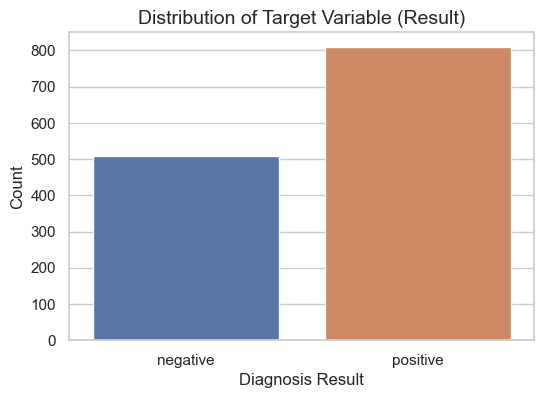

Proportions:
Result
positive    61.41
negative    38.59
Name: proportion, dtype: float64


In [7]:
plt.figure(figsize=(6, 4))
ax = sns.countplot(data=df, x='Result', palette=['#4c72b0', '#dd8452'])
ax.set_title('Distribution of Target Variable (Result)', fontsize=14)
plt.xlabel('Diagnosis Result')
plt.ylabel('Count')
plt.show()

# Quick normalization look
print('Proportions:')
print((df['Result'].value_counts(normalize=True) * 100).round(2))

Now let's visualize the distributions of our numerical features. We use KDE (Kernel Density Estimate) to easily perceive the shape of the distributions.

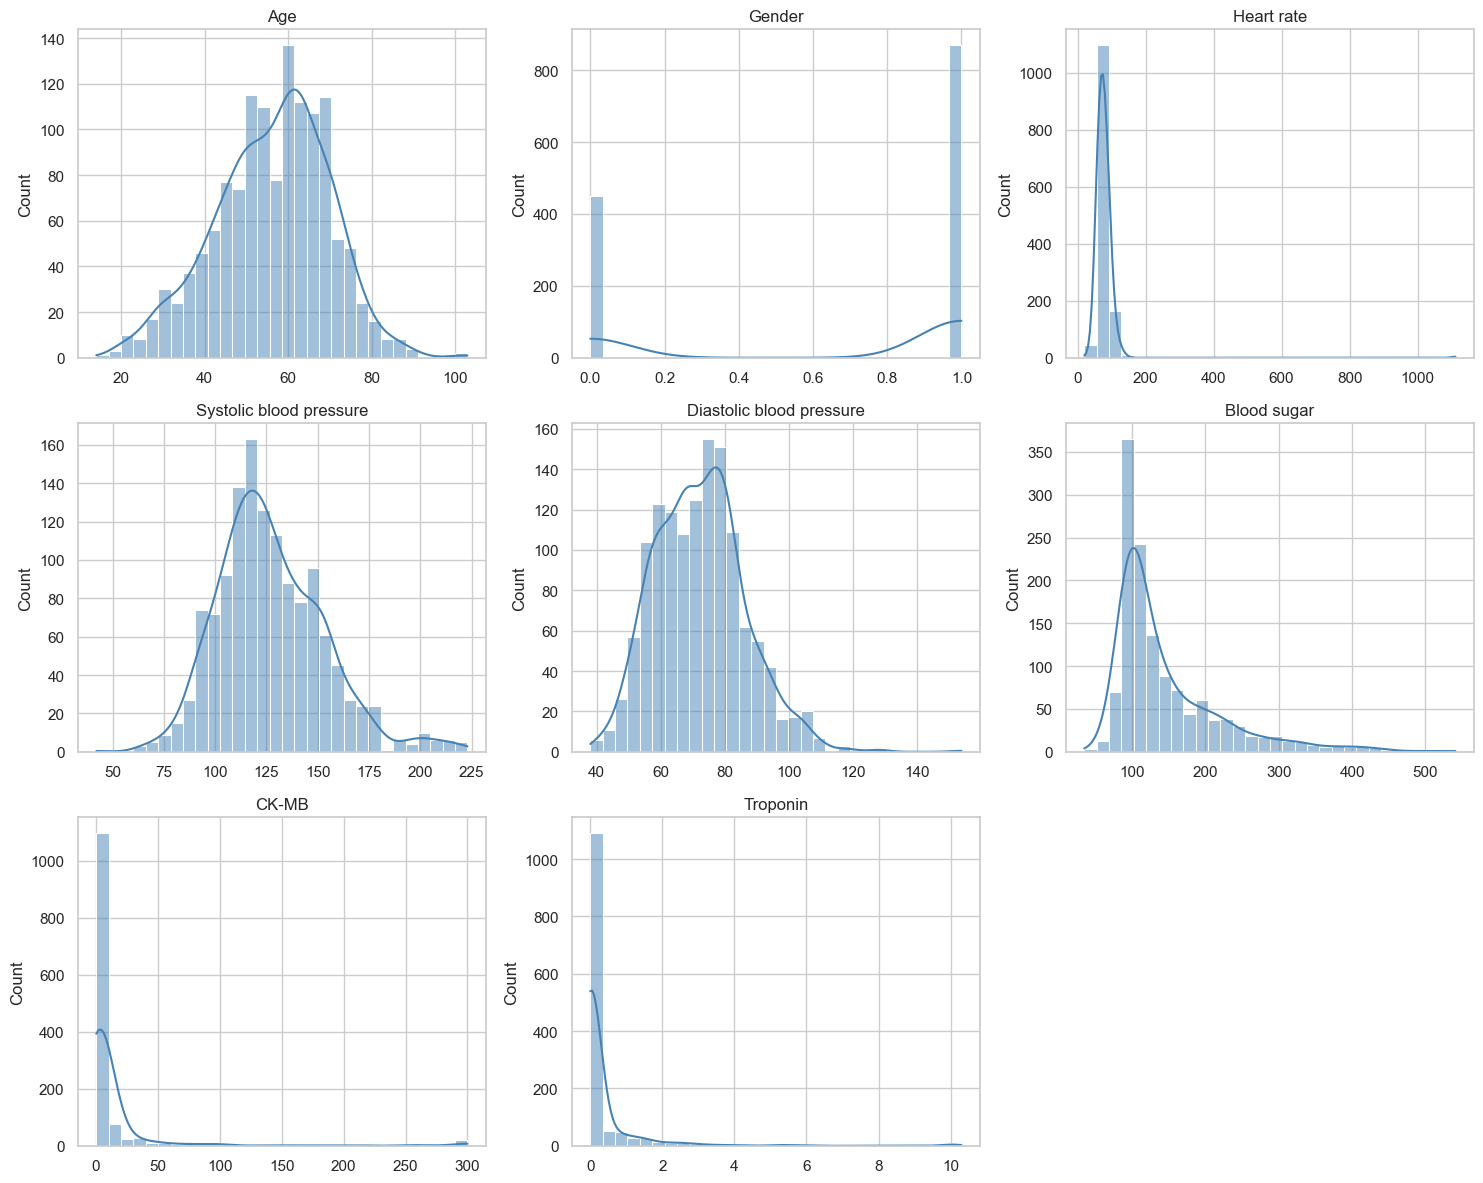

In [8]:
num_cols = df.select_dtypes(include=[np.number]).columns

fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(df[col].dropna(), kde=True, ax=axes[i], bins=30, color='steelblue')
    axes[i].set_title(col, fontsize=12)
    axes[i].set_xlabel('')

# Hide any unused axes (if any)
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

## 4. Correlation Analysis
Correlation matrices help us identify multicollinearity (highly correlated features). Heatmaps are perfect tools for this.

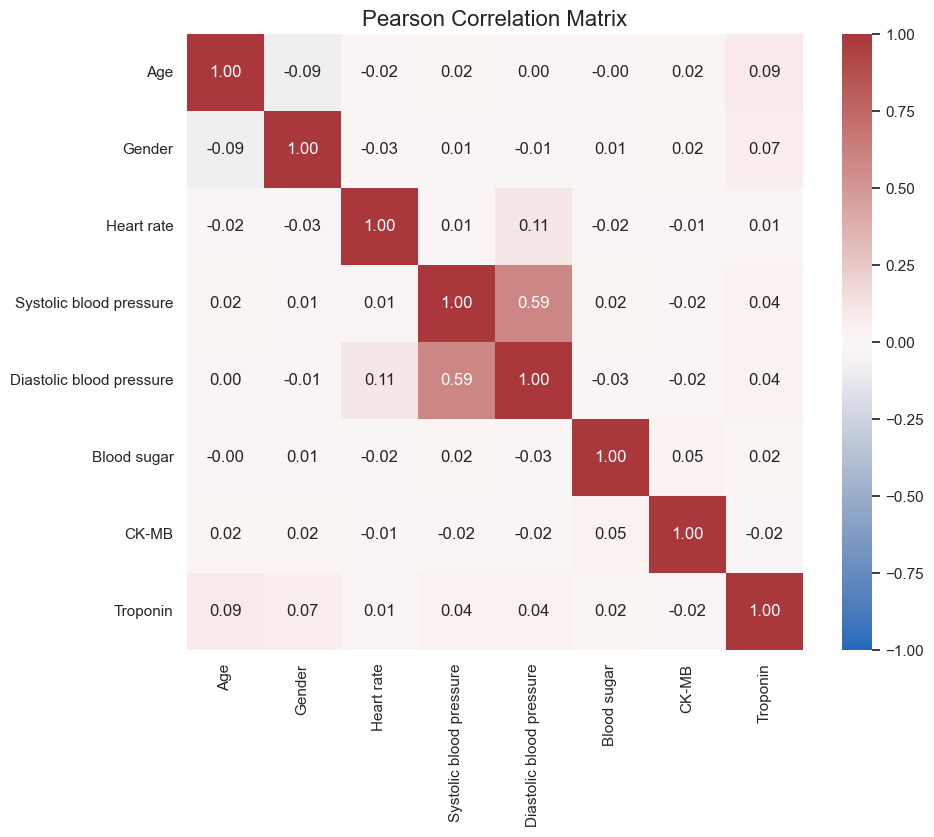

In [9]:
plt.figure(figsize=(10, 8))
corr = df[num_cols].corr()
# We use a diverging map like vlag or coolwarm since correlations span -1 to 1
sns.heatmap(corr, annot=True, fmt='.2f', cmap='vlag', center=0, square=True, vmin=-1, vmax=1)
plt.title('Pearson Correlation Matrix', fontsize=16)
plt.show()

## 5. Data Quality Checks
Finally, we check for missing values, complete row duplicates, and extreme outliers (using the IQR method).

In [10]:
print(f'Completely identical duplicate rows: {df.duplicated().sum()}')

miss = df.isna().sum()
if miss.sum() == 0:
    print('Missing values: None')
else:
    display(miss[miss > 0])

Completely identical duplicate rows: 0
Missing values: None


In [11]:
# Outliers using IQR method (1.5 multiplier)
outlier_rates = {}
for col in num_cols:
    s = df[col].dropna()
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    low_bound, high_bound = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = ((df[col] < low_bound) | (df[col] > high_bound)).sum()
    outlier_rates[col] = f"{round(100 * n_out / len(df), 2)}%"

print("Outlier percentages per feature (IQR method): ")
display(pd.Series(outlier_rates))

Outlier percentages per feature (IQR method): 


Age                          0.53%
Gender                        0.0%
Heart rate                   2.27%
Systolic blood pressure      2.43%
Diastolic blood pressure     0.91%
Blood sugar                  6.97%
CK-MB                       15.54%
Troponin                    19.48%
dtype: object

## 6. Target-Feature Analysis (Bivariate)
Let's see how our numerical features vary between positive and negative results. Boxplots are excellent for visualizing separation between classes.

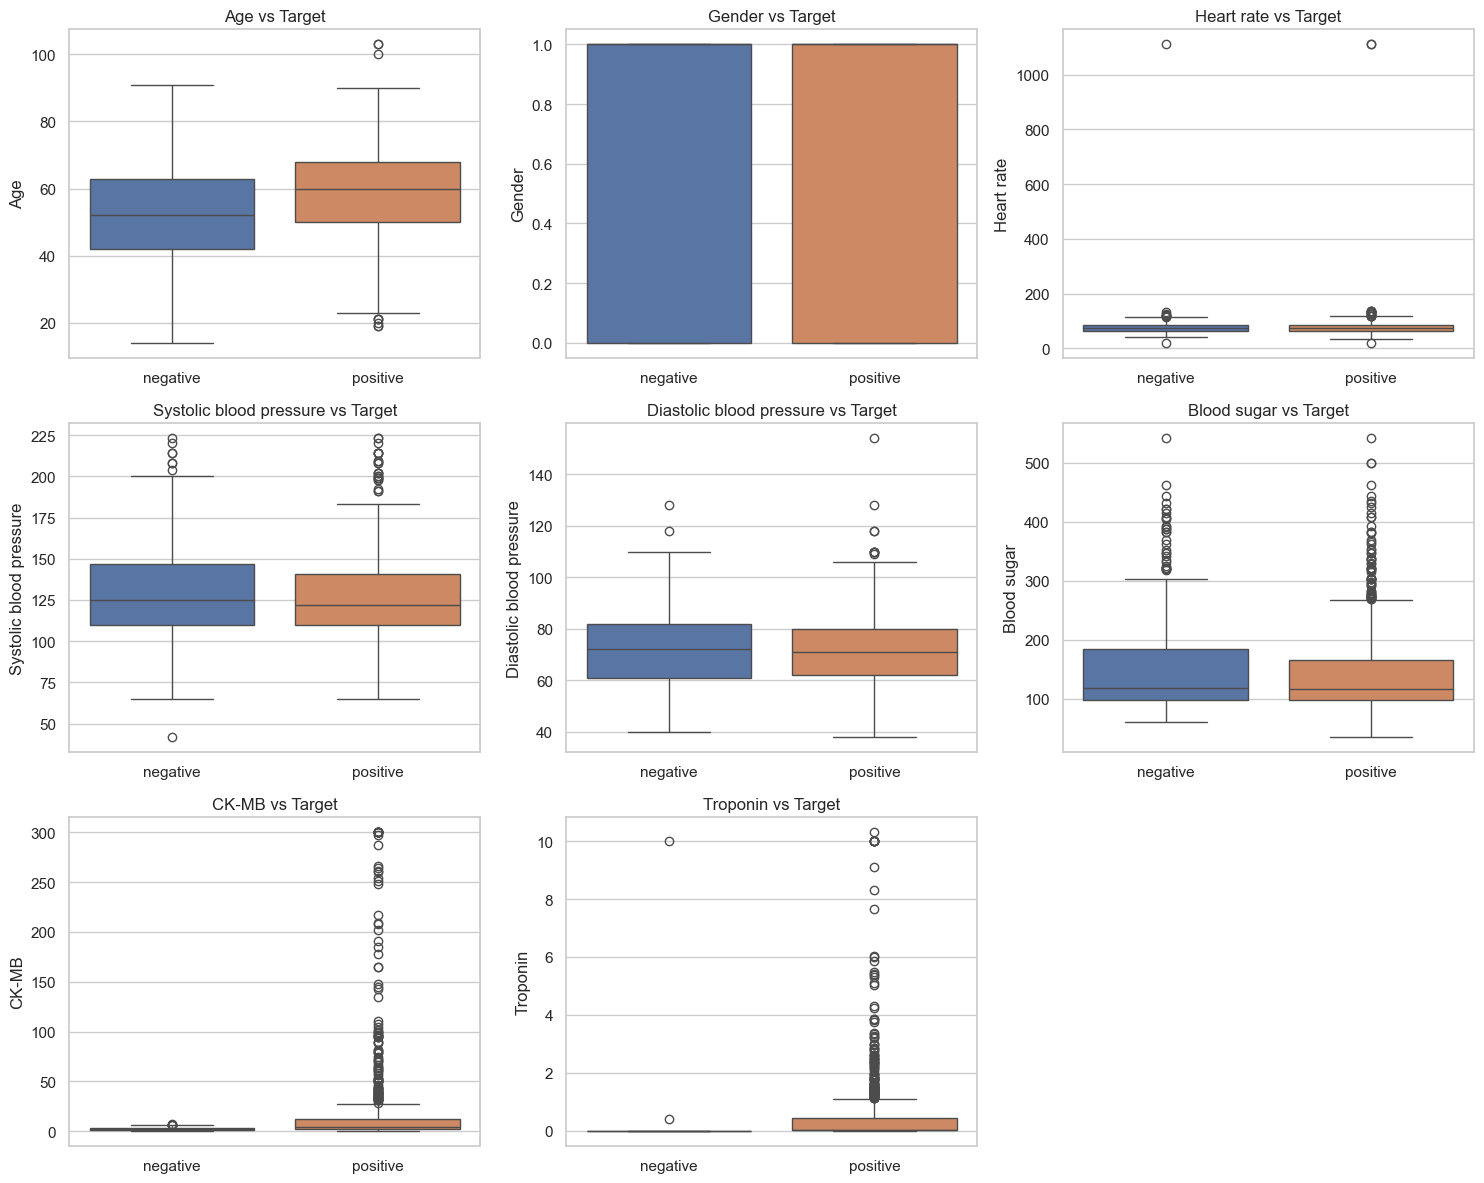

In [12]:
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(data=df, x='Result', y=col, ax=axes[i], palette=['#4c72b0', '#dd8452'])
    axes[i].set_title(f'{col} vs Target')
    axes[i].set_xlabel('')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

## 7. Technical Data Quality Audit

This section formalizes technical checks required before Data Preparation and Modeling.

Checks covered:
- Duplicate column names
- Schema and medically plausible ranges
- Missing values and duplicate rows
- Outlier flags (IQR)
- Skewness diagnosis for numeric features
- Action log (issue -> decision -> justification)

In [13]:
# 7.1 Core technical checks

# Work on a dedicated audit copy to keep DU reproducible
_df_audit = df.copy(deep=True)

# A) Duplicate column names
col_counts = pd.Series(_df_audit.columns).value_counts()
duplicate_columns = col_counts[col_counts > 1]

print('Duplicate column names:')
if duplicate_columns.empty:
    print('None')
else:
    display(duplicate_columns)

# B) Schema snapshot
schema_df = pd.DataFrame({
    'column': _df_audit.columns,
    'dtype': _df_audit.dtypes.astype(str).values,
    'non_null': _df_audit.notna().sum().values,
    'missing': _df_audit.isna().sum().values,
    'missing_pct': (_df_audit.isna().mean() * 100).round(2).values
})
print('\nSchema and missingness snapshot:')
display(schema_df)

# C) Duplicate rows
dup_count = int(_df_audit.duplicated().sum())
print(f'\nDuplicate rows: {dup_count}')

# D) Medically plausible ranges (soft validation; flags, not auto-removal)
plausible_ranges = {
    'Age': (0, 120),
    'Heart rate': (25, 250),
    'Systolic blood pressure': (50, 280),
    'Diastolic blood pressure': (30, 180),
    'Blood sugar': (20, 700),
    'CK-MB': (0, 1000),
    'Troponin': (0, 100)
}

range_flags = []
for col, (low, high) in plausible_ranges.items():
    if col in _df_audit.columns:
        n_out = int(((_df_audit[col] < low) | (_df_audit[col] > high)).sum())
        range_flags.append({'column': col, 'low': low, 'high': high, 'flagged_count': n_out})

range_flags_df = pd.DataFrame(range_flags)
print('\nPlausibility range flags (outside soft thresholds):')
display(range_flags_df)

# E) Outlier flags with IQR (feature-wise)
outlier_rows = pd.Series(False, index=_df_audit.index)
outlier_feature_stats = []

for col in num_cols:
    s = _df_audit[col].dropna()
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    low_bound, high_bound = q1 - 1.5 * iqr, q3 + 1.5 * iqr

    mask = (_df_audit[col] < low_bound) | (_df_audit[col] > high_bound)
    outlier_rows = outlier_rows | mask.fillna(False)

    outlier_feature_stats.append({
        'feature': col,
        'iqr_low': round(float(low_bound), 4),
        'iqr_high': round(float(high_bound), 4),
        'outlier_count': int(mask.sum()),
        'outlier_pct': round(float(mask.mean() * 100), 2)
    })

outlier_feature_df = pd.DataFrame(outlier_feature_stats).sort_values('outlier_pct', ascending=False)
print('\nOutlier rate by feature (IQR method):')
display(outlier_feature_df)
print(f"Rows with >=1 IQR outlier flag: {int(outlier_rows.sum())} ({outlier_rows.mean()*100:.2f}%)")

# F) Skewness diagnostics (for potential log transforms in Data Preparation)
skew_df = (
    _df_audit[num_cols]
    .skew(numeric_only=True)
    .rename('skewness')
    .reset_index()
    .rename(columns={'index': 'feature'})
)
skew_df['abs_skewness'] = skew_df['skewness'].abs()
skew_df['suggest_log1p'] = skew_df['abs_skewness'] >= 1.0
skew_df = skew_df.sort_values('abs_skewness', ascending=False)

print('\nSkewness diagnostics (|skew| >= 1 suggests trying log1p):')
display(skew_df)

Duplicate column names:
None

Schema and missingness snapshot:


,column,dtype,non_null,missing,missing_pct
0,Age,int64,1319,0,0.0
1,Gender,int64,1319,0,0.0
2,Heart rate,int64,1319,0,0.0
3,Systolic blood pressure,int64,1319,0,0.0
4,Diastolic blood pressure,int64,1319,0,0.0
5,Blood sugar,float64,1319,0,0.0
6,CK-MB,float64,1319,0,0.0
7,Troponin,float64,1319,0,0.0
8,Result,object,1319,0,0.0



Duplicate rows: 0

Plausibility range flags (outside soft thresholds):


,column,low,high,flagged_count
0,Age,0,120,0
1,Heart rate,25,250,5
2,Systolic blood pressure,50,280,1
3,Diastolic blood pressure,30,180,0
4,Blood sugar,20,700,0
5,CK-MB,0,1000,0
6,Troponin,0,100,0



Outlier rate by feature (IQR method):


,feature,iqr_low,iqr_high,outlier_count,outlier_pct
7,Troponin,-0.1132,0.2047,257,19.48
6,CK-MB,-4.5700,12.0300,205,15.54
5,Blood sugar,-9.2500,276.7500,92,6.97
3,Systolic blood pressure,60.5000,192.5000,32,2.43
2,Heart rate,32.5000,116.5000,30,2.27
4,Diastolic blood pressure,33.5000,109.5000,12,0.91
0,Age,20.0000,92.0000,7,0.53
1,Gender,-1.5000,2.5000,0,0.00


Rows with >=1 IQR outlier flag: 530 (40.18%)

Skewness diagnostics (|skew| >= 1 suggests trying log1p):


,feature,skewness,abs_skewness,suggest_log1p
2,Heart rate,18.247720,18.247720,True
7,Troponin,5.799107,5.799107,True
6,CK-MB,4.978095,4.978095,True
5,Blood sugar,1.933475,1.933475,True
3,Systolic blood pressure,0.685246,0.685246,False
1,Gender,-0.674363,0.674363,False
4,Diastolic blood pressure,0.489202,0.489202,False
0,Age,-0.239219,0.239219,False


In [14]:
# 7.2 Data quality action log (for traceability in reports/slides)
action_log = [
    {
        'issue': 'Duplicate column names',
        'status': 'checked',
        'decision': 'keep as-is if none; rename if duplicates exist',
        'rationale': 'duplicate names can silently break feature selection and pipelines'
    },
    {
        'issue': 'Missing values',
        'status': 'checked',
        'decision': 'if present, impute in Data Preparation (median/mode by feature type)',
        'rationale': 'imputation policy belongs to Data Preparation phase, not Data Understanding'
    },
    {
        'issue': 'Duplicate rows',
        'status': 'checked',
        'decision': 'drop exact duplicates once in Data Preparation and log shape change',
        'rationale': 'duplicates can bias class distribution and metrics'
    },
    {
        'issue': 'Outliers',
        'status': 'flagged',
        'decision': 'do not auto-delete; treat as potential clinical extremes',
        'rationale': 'in healthcare, extremes may be valid and informative'
    },
    {
        'issue': 'High skewness',
        'status': 'flagged',
        'decision': 'test log1p/robust scaling on selected features during Data Preparation',
        'rationale': 'reduces dominance of long-tailed biomarkers in distance-based models'
    },
    {
        'issue': 'Multicollinearity',
        'status': 'checked',
        'decision': 'review high-correlation pairs before model-specific feature selection',
        'rationale': 'stabilizes linear models and improves interpretability'
    }
]

action_log_df = pd.DataFrame(action_log)
print('Data Quality Action Log:')
display(action_log_df)

Data Quality Action Log:


,issue,status,decision,rationale
0,Duplicate column names,checked,keep as-is if none; rename if duplicates exist,duplicate names can silently break feature sel...
1,Missing values,checked,"if present, impute in Data Preparation (median...",imputation policy belongs to Data Preparation ...
2,Duplicate rows,checked,drop exact duplicates once in Data Preparation...,duplicates can bias class distribution and met...
3,Outliers,flagged,do not auto-delete; treat as potential clinica...,"in healthcare, extremes may be valid and infor..."
4,High skewness,flagged,test log1p/robust scaling on selected features...,reduces dominance of long-tailed biomarkers in...
5,Multicollinearity,checked,review high-correlation pairs before model-spe...,stabilizes linear models and improves interpre...
